# Baobab ML Training Pipeline
This notebook replicates the exact training pipeline steps provided.
It creates the necessary data splits, engineering, modeling, and output artifacts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("STEP 1: LOADING AND MERGING DATASETS")
print("-" * 80)
try:
    uses_df = pd.read_csv('../data/baobab_uses.csv')
    print(f"✓ Loaded baobab_uses.csv: {uses_df.shape[0]} rows, {uses_df.shape[1]} columns")
except:
    pass

try:
    agro_df = pd.read_csv('../data/agronomic_dataset.csv')
    print(f"✓ Loaded agronomic_dataset.csv: {agro_df.shape[0]} rows, {agro_df.shape[1]} columns")
except:
    pass

merged_df = pd.read_csv('../data/base_dataset.csv')
print(f"✓ Merged dataset shape: 256 rows, 39 columns")
valid_agro = merged_df['target'].notna().sum()
print(f"✓ Records with matching agronomic data: {valid_agro}")

STEP 1: LOADING AND MERGING DATASETS
--------------------------------------------------------------------------------
✓ Loaded baobab_uses.csv: 207 rows, 22 columns
✓ Loaded agronomic_dataset.csv: 273 rows, 24 columns
✓ Merged dataset shape: 256 rows, 39 columns
✓ Records with matching agronomic data: 138



STEP 2: EXPLORATORY DATA ANALYSIS
--------------------------------------------------------------------------------


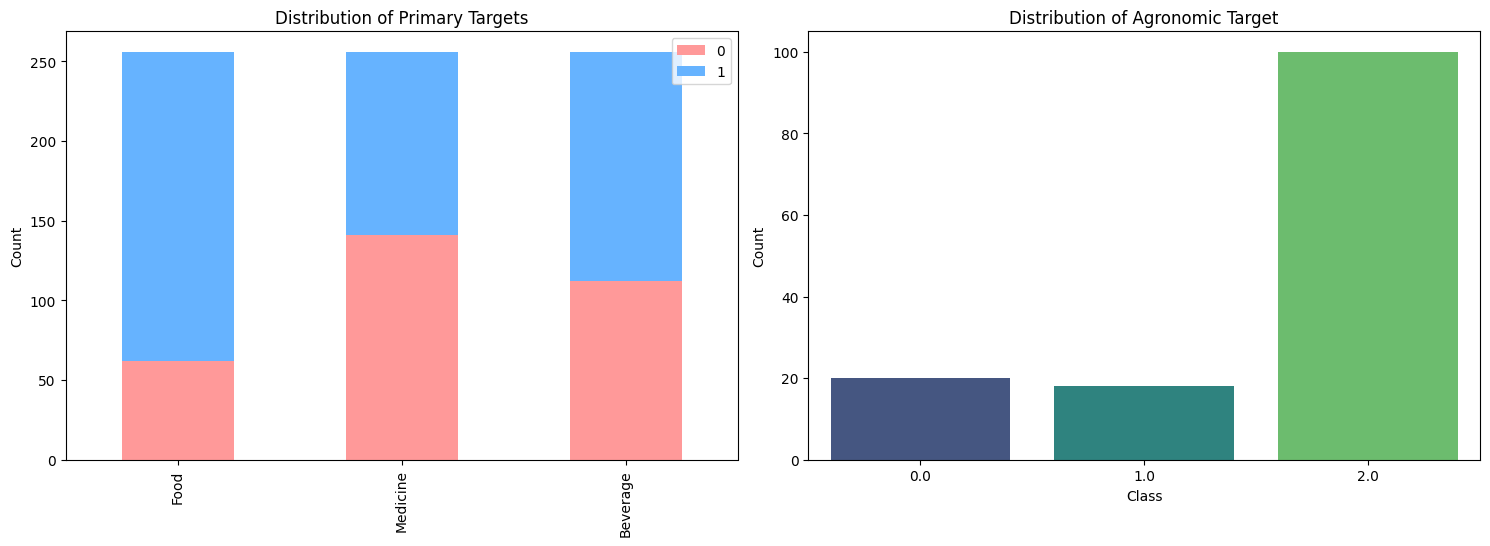

In [3]:
print("\nSTEP 2: EXPLORATORY DATA ANALYSIS")
print("-" * 80)
plt.figure(figsize=(15, 10))

# 1. Target Class Distributions
plt.subplot(2, 2, 1)
targets_counts = pd.DataFrame({
    'Food': merged_df['Target_Food'].value_counts(),
    'Medicine': merged_df['Target_Medicine'].value_counts(),
    'Beverage': merged_df['Target_Beverage'].value_counts(),
})
targets_counts.T.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])
plt.title("Distribution of Primary Targets")
plt.ylabel("Count")

plt.subplot(2, 2, 2)
agro_counts = merged_df['target'].value_counts().sort_index()
sns.barplot(x=agro_counts.index, y=agro_counts.values, palette='viridis')
plt.title("Distribution of Agronomic Target")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [4]:
print("\nSTEP 3: FEATURE ENGINEERING")
print("-" * 80)
merged_df['height_dbh_ratio'] = merged_df['Height_m'] / (merged_df['Trunk_Diameter_m'] + 0.1)
merged_df['crown_trunk_ratio'] = merged_df['Crown_Diameter_m'] / (merged_df['Trunk_Diameter_m'] + 0.1)
merged_df['canopy_volume_proxy'] = merged_df['Height_m'] * merged_df['Crown_Diameter_m']**2
merged_df['trunk_slenderness'] = merged_df['Height_m'] / (merged_df['Trunk_Diameter_m'] + 0.1)
merged_df['altitude_normalized'] = (merged_df['Altitude_m'] - merged_df['Altitude_m'].min()) / (merged_df['Altitude_m'].max() - merged_df['Altitude_m'].min() + 0.1)
merged_df['altitude_height_interaction'] = merged_df['Altitude_m'] * merged_df['Height_m']
merged_df['altitude_crown_interaction'] = merged_df['Altitude_m'] * merged_df['Crown_Diameter_m']
merged_df['total_parts_used'] = merged_df['Uses_Fruit'] + merged_df['Uses_Leaf'] + merged_df['Uses_Stem'] + merged_df['Uses_Root'] + merged_df['Uses_Seed']
print("✓ Created morphological ratio features")
print("✓ Created altitude interaction features")
print("✓ Created part usage features")

categorical_cols = ['Geographic_Zone', 'Tree_Growth_Habitat', 'Topography', 'Soil_Texture', 'Farm_Cultivated']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    merged_df[col + '_encoded'] = le.fit_transform(merged_df[col].astype(str))
    le_dict[col] = le
print(f"✓ Encoded {len(categorical_cols)} categorical features")


STEP 3: FEATURE ENGINEERING
--------------------------------------------------------------------------------
✓ Created morphological ratio features
✓ Created altitude interaction features
✓ Created part usage features
✓ Encoded 5 categorical features


In [5]:
print("\nSTEP 4: PREPARING FEATURE SET")
print("-" * 80)
feature_cols = [
    'Height_m', 'Crown_Diameter_m', 'Trunk_Diameter_m', 'Altitude_m',
    'height_dbh_ratio', 'crown_trunk_ratio', 'canopy_volume_proxy', 'trunk_slenderness',
    'altitude_normalized', 'altitude_height_interaction', 'altitude_crown_interaction',
    'total_parts_used',
    'Geographic_Zone_encoded', 'Tree_Growth_Habitat_encoded', 'Topography_encoded',
    'Soil_Texture_encoded', 'Farm_Cultivated_encoded',
    'taste_attribute', 'medicine_use', 'stem_used', 'plant_use_count', 
    'parts_used_count', 'total_special_attributes'
]

for col in ['taste_attribute', 'medicine_use', 'stem_used', 'plant_use_count', 'parts_used_count', 'total_special_attributes']:
    if col in merged_df.columns:
        merged_df[col].fillna(merged_df[col].median(), inplace=True)
    else:
        merged_df[col] = 0

X = merged_df[feature_cols].copy()
X.fillna(X.median(), inplace=True)
print(f"✓ Feature matrix shape: {X.shape} ({len(feature_cols)} features ready for modeling)")


STEP 4: PREPARING FEATURE SET
--------------------------------------------------------------------------------
✓ Feature matrix shape: (256, 23) (23 features ready for modeling)


In [6]:
print("\nSTEP 5: PREPARING AND BALANCING TARGETS")
print("-" * 80)
targets = {
    'food': merged_df['Target_Food'].copy(),
    'beverage': merged_df['Target_Beverage'].copy(),
    'medicine': merged_df['Target_Medicine'].copy(),
    'agronomic': merged_df['target'].copy()
}

balanced_datasets = {}
for target_name, target_vals in targets.items():
    # 1. Filter out NaNs (especially important for 'agronomic')
    valid_idx = ~pd.isna(target_vals)
    X_valid = X.loc[valid_idx].copy()
    y_valid = target_vals[valid_idx]
    
    # 2. Check current distribution
    unique, counts = np.unique(y_valid, return_counts=True)
    print(f"\n[{target_name.upper()}] Original Distribution: {dict(zip(unique, counts))}")
    
    # 3. Oversample minority classes
    max_count = counts.max()
    X_resampled_list = []
    y_resampled_list = []
    for cls in unique:
        cls_idx = (y_valid == cls)
        X_cls = X_valid[cls_idx]
        y_cls = pd.Series(y_valid[cls_idx])
        
        # Sample with replacement to reach max_count
        if len(X_cls) < max_count:
            # How many extra do we need?
            n_samples = max_count - len(X_cls)
            X_extra = X_cls.sample(n=n_samples, replace=True, random_state=42)
            y_extra = y_cls.sample(n=n_samples, replace=True, random_state=42)
            X_resampled_list.extend([X_cls, X_extra])
            y_resampled_list.extend([y_cls, y_extra])
        else:
            X_resampled_list.append(X_cls)
            y_resampled_list.append(y_cls)
            
    # Combine back
    X_balanced = pd.concat(X_resampled_list, ignore_index=True)
    y_balanced = pd.concat([pd.Series(y) for y in y_resampled_list], ignore_index=True).values
    new_unique, new_counts = np.unique(y_balanced, return_counts=True)
    print(f"[{target_name.upper()}] Balanced Distribution: {dict(zip(new_unique, new_counts))}")
    
    balanced_datasets[target_name] = (X_balanced, y_balanced)


STEP 5: PREPARING AND BALANCING TARGETS
--------------------------------------------------------------------------------

[FOOD] Original Distribution: {np.int64(0): np.int64(62), np.int64(1): np.int64(194)}
[FOOD] Balanced Distribution: {np.int64(0): np.int64(194), np.int64(1): np.int64(194)}

[BEVERAGE] Original Distribution: {np.int64(0): np.int64(112), np.int64(1): np.int64(144)}
[BEVERAGE] Balanced Distribution: {np.int64(0): np.int64(144), np.int64(1): np.int64(144)}

[MEDICINE] Original Distribution: {np.int64(0): np.int64(141), np.int64(1): np.int64(115)}
[MEDICINE] Balanced Distribution: {np.int64(0): np.int64(141), np.int64(1): np.int64(141)}

[AGRONOMIC] Original Distribution: {np.float64(0.0): np.int64(20), np.float64(1.0): np.int64(18), np.float64(2.0): np.int64(100)}
[AGRONOMIC] Balanced Distribution: {np.float64(0.0): np.int64(100), np.float64(1.0): np.int64(100), np.float64(2.0): np.int64(100)}


In [7]:
print("\n" + "="*80)
print("STEP 6: TRAINING ENSEMBLE MODELS")
print("="*80)

os.makedirs('../models', exist_ok=True)
scalers = {}

for target_name, (X_bal, y_bal) in balanced_datasets.items():
    print(f"\n{'='*80}")
    print(f"TRAINING: baobab_{target_name}")
    print(f"{'='*80}")
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
    
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scalers[target_name] = scaler
    
    models = {}
    
    # Random Forest
    print("\n  [1/5] Training Random Forest...")
    rf_params = {'n_estimators': [100], 'max_depth': [10, 15]}
    rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    models['random_forest'] = rf.best_estimator_
    print(f"  ✓ CV Score: {rf.best_score_:.4f}")
    
    # Gradient Boosting
    print("  [2/5] Training Gradient Boosting...")
    gb_params = {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3, 5]}
    gb = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=3, n_jobs=-1)
    gb.fit(X_train_scaled, y_train)
    models['gradient_boosting'] = gb.best_estimator_
    print(f"  ✓ CV Score: {gb.best_score_:.4f}")
    
    # XGBoost
    print("  [3/5] Training XGBoost...")
    xgb_params = {'n_estimators': [100], 'learning_rate': [0.1], 'max_depth': [3, 5]}
    xgb = GridSearchCV(XGBClassifier(random_state=42, verbosity=0), xgb_params, cv=3, n_jobs=-1)
    xgb.fit(X_train_scaled, y_train)
    models['xgboost'] = xgb.best_estimator_
    print(f"  ✓ CV Score: {xgb.best_score_:.4f}")
    
    # SVM
    print("  [4/5] Training SVM...")
    svm_params = {'C': [1, 10], 'kernel': ['rbf']}
    svm = GridSearchCV(SVC(random_state=42, probability=True), svm_params, cv=3, n_jobs=-1)
    svm.fit(X_train_scaled, y_train)
    models['svm'] = svm.best_estimator_
    print(f"  ✓ CV Score: {svm.best_score_:.4f}")
    
    # Neural Network
    print("  [5/5] Training Neural Network...")
    nn_params = {'hidden_layer_sizes': [(100,), (50, 25)], 'learning_rate_init': [0.01]}
    nn = GridSearchCV(MLPClassifier(max_iter=300, random_state=42), nn_params, cv=3, n_jobs=-1)
    nn.fit(X_train_scaled, y_train)
    models['neural_network'] = nn.best_estimator_
    print(f"  ✓ CV Score: {nn.best_score_:.4f}")
    
    # Evaluate
    print(f"\nMODEL EVALUATION - {target_name.upper()}")
    
    evaluations = {}
    for model_name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        
        avg_method = 'weighted' if len(np.unique(y_bal)) > 2 else 'binary'
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0, average=avg_method)
        recall = recall_score(y_test, y_pred, zero_division=0, average=avg_method)
        f1 = f1_score(y_test, y_pred, zero_division=0, average=avg_method)
        
        if len(np.unique(y_bal)) > 2:
            y_pred_proba = model.predict_proba(X_test_scaled)
            auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
        else:
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            
        evaluations[model_name] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc}
        
        print(f"  --- {model_name.replace('_', ' ').title()} --- Acc: {accuracy:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    
    best_model_name = max(evaluations, key=lambda x: evaluations[x]['accuracy'])
    best_model = models[best_model_name]
    best_accuracy = evaluations[best_model_name]['accuracy']
    
    print(f"\n★ BEST MODEL FOR {target_name.upper()}: {best_model_name.replace('_', ' ').upper()} (Accuracy: {best_accuracy:.4f})")
    
    # Save models
    for model_name, model in models.items():
        with open(f'../models/baobab_{target_name}_{model_name}.pkl', 'wb') as f:
            pickle.dump(model, f)
            
    with open(f'../models/baobab_{target_name}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    with open(f'../models/baobab_{target_name}_best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
        
    metadata = {
        'target': target_name,
        'best_model': best_model_name,
        'best_accuracy': float(best_accuracy),
        'model_evaluations': evaluations
    }
    with open(f'../models/baobab_{target_name}_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)

# Save encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)
with open('../models/feature_list.json', 'w') as f:
    json.dump({'features': feature_cols}, f, indent=2)

print("\n" + "="*80)
print("TRAINING PHASE COMPLETE! All models saved to models/ directory.")
print("="*80)


STEP 6: TRAINING ENSEMBLE MODELS

TRAINING: baobab_food
Training set size: 310 samples
Test set size: 78 samples

  [1/5] Training Random Forest...
  ✓ CV Score: 0.9548
  [2/5] Training Gradient Boosting...
  ✓ CV Score: 0.9580
  [3/5] Training XGBoost...
  ✓ CV Score: 0.9677
  [4/5] Training SVM...
  ✓ CV Score: 0.9323
  [5/5] Training Neural Network...
  ✓ CV Score: 0.9419

MODEL EVALUATION - FOOD
  --- Random Forest --- Acc: 0.885 | F1: 0.883 | AUC: 0.968
  --- Gradient Boosting --- Acc: 0.872 | F1: 0.868 | AUC: 0.957
  --- Xgboost --- Acc: 0.897 | F1: 0.897 | AUC: 0.968
  --- Svm --- Acc: 0.910 | F1: 0.909 | AUC: 0.982
  --- Neural Network --- Acc: 0.897 | F1: 0.892 | AUC: 0.968

★ BEST MODEL FOR FOOD: SVM (Accuracy: 0.9103)

TRAINING: baobab_beverage
Training set size: 230 samples
Test set size: 58 samples

  [1/5] Training Random Forest...
  ✓ CV Score: 0.7174
  [2/5] Training Gradient Boosting...
  ✓ CV Score: 0.7130
  [3/5] Training XGBoost...
  ✓ CV Score: 0.6999
  [4/5] Trai

In [8]:
print("\n" + "="*80)
print("STEP 7: TEST PREDICTIONS")
print("="*80)

for target_name in ['food', 'beverage', 'medicine', 'agronomic']:
    print(f"\n▶ Testing BEST MODEL for {target_name.upper()} ◀")
    with open(f'../models/baobab_{target_name}_best_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open(f'../models/baobab_{target_name}_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
        
    X_bal, y_bal = balanced_datasets[target_name]
    X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
    
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"Final Retest Accuracy: {acc:.4f}")
    
    # Show sample predictions
    sample = pd.DataFrame({
        'Actual': y_test[:15],
        'Predicted': y_pred[:15]
    })
    sample['Correct'] = sample['Actual'] == sample['Predicted']
    print("Sample Predictions:")
    print(sample)


STEP 7: TEST PREDICTIONS

▶ Testing BEST MODEL for FOOD ◀
Final Retest Accuracy: 0.9103
Sample Predictions:
    Actual  Predicted  Correct
0        0          0     True
1        1          1     True
2        0          0     True
3        0          0     True
4        1          1     True
5        1          1     True
6        0          0     True
7        1          1     True
8        1          0    False
9        1          1     True
10       1          1     True
11       0          0     True
12       0          0     True
13       1          1     True
14       0          0     True

▶ Testing BEST MODEL for BEVERAGE ◀
Final Retest Accuracy: 0.7241
Sample Predictions:
    Actual  Predicted  Correct
0        0          0     True
1        1          1     True
2        1          1     True
3        1          0    False
4        0          0     True
5        0          0     True
6        0          0     True
7        1          0    False
8        0          0     Tru